# Лабораторная работа №1. Линейная регрессия и факторный анализ

**Датасет:** Red Wine Quality (Kaggle, `winequality-red.csv`) — физико-химические свойства красного вина и его экспертная оценка.

**Цель работы:** изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качество.

**Постановка задачи:**
1. Загрузить датасет из репозитория (например, kaggle.com или аналогичных платформ).
2. Подготовить данные: провести первичный анализ, визуализировать распределение признаков и целевой переменной. 
3. Провести предобработку данных: удалить пропущенные значения, закодировать категориальные переменные (опционально).
4. Построить матрицу корреляций. Сделать выводы о наличии мультиколлинеарности (расчет VIF-коэффициента).
5. Построить регрессионные модели (линейная, лассо и гребневая). Если целевая переменная - категориальная, то исследовать логистическую регрессию. Разделить на тренировочную и тестовую выборки (80/20 или 70/30). Использовать кросс-валидацию. Оценить качество построенной модели с помощью метрик: RMSE (Root Mean Square Error), R² (коэффициент детерминации) и MAPE (Mean Absolute Percentage Error).
6. Устранить мультиколлинеарность и снизить размерность признаков с помощью метода главных компонент (PCA). Перед проведением PCA провести стандартизацию данных.
7. Повторить шаг 5 (линейная, лассо и гребневая регрессия), но использовать в качестве признаков не исходные данные, а главные компоненты. Сравнить метрики качества (RMSE, R² и MAPE) моделей, обученных на исходных данных и на главных компонентах.
**Метрики:** RMSE, R², MAPE. Разбиение 80/20, 5-кратная кросс-валидация.

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

Подключаем библиотеки: `pandas`/`numpy` — данные, `matplotlib`/`seaborn` — графики, `statsmodels` — расчёт VIF и тест на гетероскедастичность, `scikit-learn` — разбиение выборки, стандартизация, PCA, модели и метрики. `RANDOM_STATE = 42` фиксирует случайность, чтобы результаты воспроизводились при перезапуске.

In [5]:
df = pd.read_csv("winequality-red.csv")
print("Размер датасета (строк, столбцов):", df.shape)
df.head()

Размер датасета (строк, столбцов): (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 1. Описание датасета

Датасет содержит **1599 образцов красного вина** (португальское вино *Vinho Verde*) и **12 столбцов**: 11 физико-химических признаков и целевую переменную `quality` — оценку качества. Все признаки числовые, категориальных нет.

| Признак | Описание |
| --- | --- |
| `fixed acidity` | нелетучие кислоты (винная), г/дм³ |
| `volatile acidity` | летучие кислоты (уксусная), г/дм³; в избытке дают привкус уксуса |
| `citric acid` | лимонная кислота, г/дм³ |
| `residual sugar` | остаточный сахар, г/дм³ |
| `chlorides` | хлориды (соль), г/дм³ |
| `free sulfur dioxide` | свободный SO₂, мг/дм³ |
| `total sulfur dioxide` | общий SO₂, мг/дм³ |
| `density` | плотность, г/см³ |
| `pH` | кислотность (чем меньше, тем кислее) |
| `sulphates` | сульфаты, г/дм³ |
| `alcohol` | содержание алкоголя, % об. |
| **`quality`** | **целевая переменная** — оценка качества (целое число) |

Первые строки подтверждают, что данные загрузились корректно: значения лежат в ожидаемых диапазонах, а строки 0 и 4 выглядят одинаково, что намекает на наличие дубликатов (проверим ниже).

In [6]:
df.info()
print()
print("Пропущенных значений всего:", df.isna().sum().sum())
print("Полных дубликатов строк:", df.duplicated().sum())
df.describe().T.round(3)

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB

Пропущенных значений всего: 0
Полных дубликатов строк: 240


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.320,1.741,4.600,7.100,7.900,9.200,15.900
volatile acidity,1599.0,0.528,0.179,0.120,0.390,0.520,0.640,1.580
citric acid,1599.0,0.271,0.195,0.000,0.090,0.260,0.420,1.000
residual sugar,1599.0,2.539,1.410,0.900,1.900,2.200,2.600,15.500
chlorides,1599.0,0.087,0.047,0.012,0.070,0.079,0.090,0.611
free sulfur dioxide,1599.0,15.875,10.460,1.000,7.000,14.000,21.000,72.000
total sulfur dioxide,1599.0,46.468,32.895,6.000,22.000,38.000,62.000,289.000
density,1599.0,0.997,0.002,0.990,0.996,0.997,0.998,1.004
pH,1599.0,3.311,0.154,2.740,3.210,3.310,3.400,4.010
sulphates,1599.0,0.658,0.170,0.330,0.550,0.620,0.730,2.000


Результаты первичного анализа:

- **Пропусков нет** — все 1599 значений в каждом столбце заполнены.
- **Полных дубликатов 240** (около 15% выборки). Это вина с абсолютно одинаковыми измерениями и оценкой. Если оставить их, одинаковые строки могут попасть и в train, и в test, и тестовая метрика станет завышенной, поэтому ниже дубликаты удаляются.
- **Масштабы признаков сильно различаются:** `density` меняется в пределах 0.990–1.004, а `total sulfur dioxide` — от 6 до 289. Поэтому перед обучением нужна стандартизация (иначе регуляризация и PCA будут «видеть» только признаки с большим масштабом).
- У `chlorides`, `residual sugar`, `sulphates`, `total sulfur dioxide` максимум намного больше 75-го перцентиля — это правосторонние выбросы (проверим на графиках).

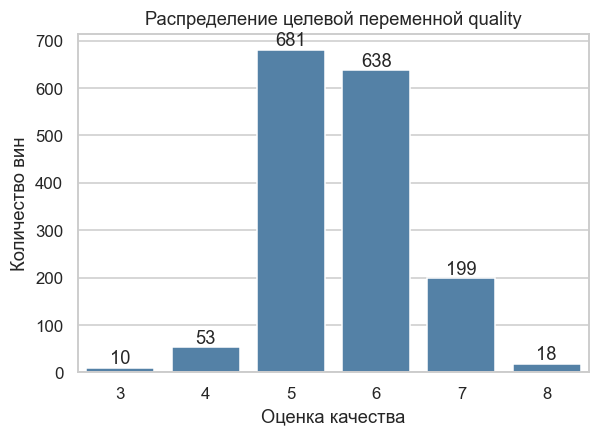

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x="quality", data=df, color="steelblue", ax=ax)
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
ax.set_title("Распределение целевой переменной quality")
ax.set_xlabel("Оценка качества")
ax.set_ylabel("Количество вин")
plt.show()

**Целевая переменная `quality`** — целое число от 3 до 8, но фактически почти все вина получили оценки 5 и 6 (вместе около 82% выборки); крайние классы (3 и 8) очень редки: 10 и 18 образцов. Распределение близко к колоколообразному, но дискретное и сосредоточено вокруг среднего 5.64.

Две последствия для работы:
1. Так как оценка упорядоченная, а шагов много (6 значений), задача решается как **регрессия** (а не логистическая регрессия, которая нужна для категориальной цели по условию задания).
2. Модель будет «стягивать» прогнозы к середине (5–6) и плохо предсказывать редкие крайние оценки — это ограничит R².

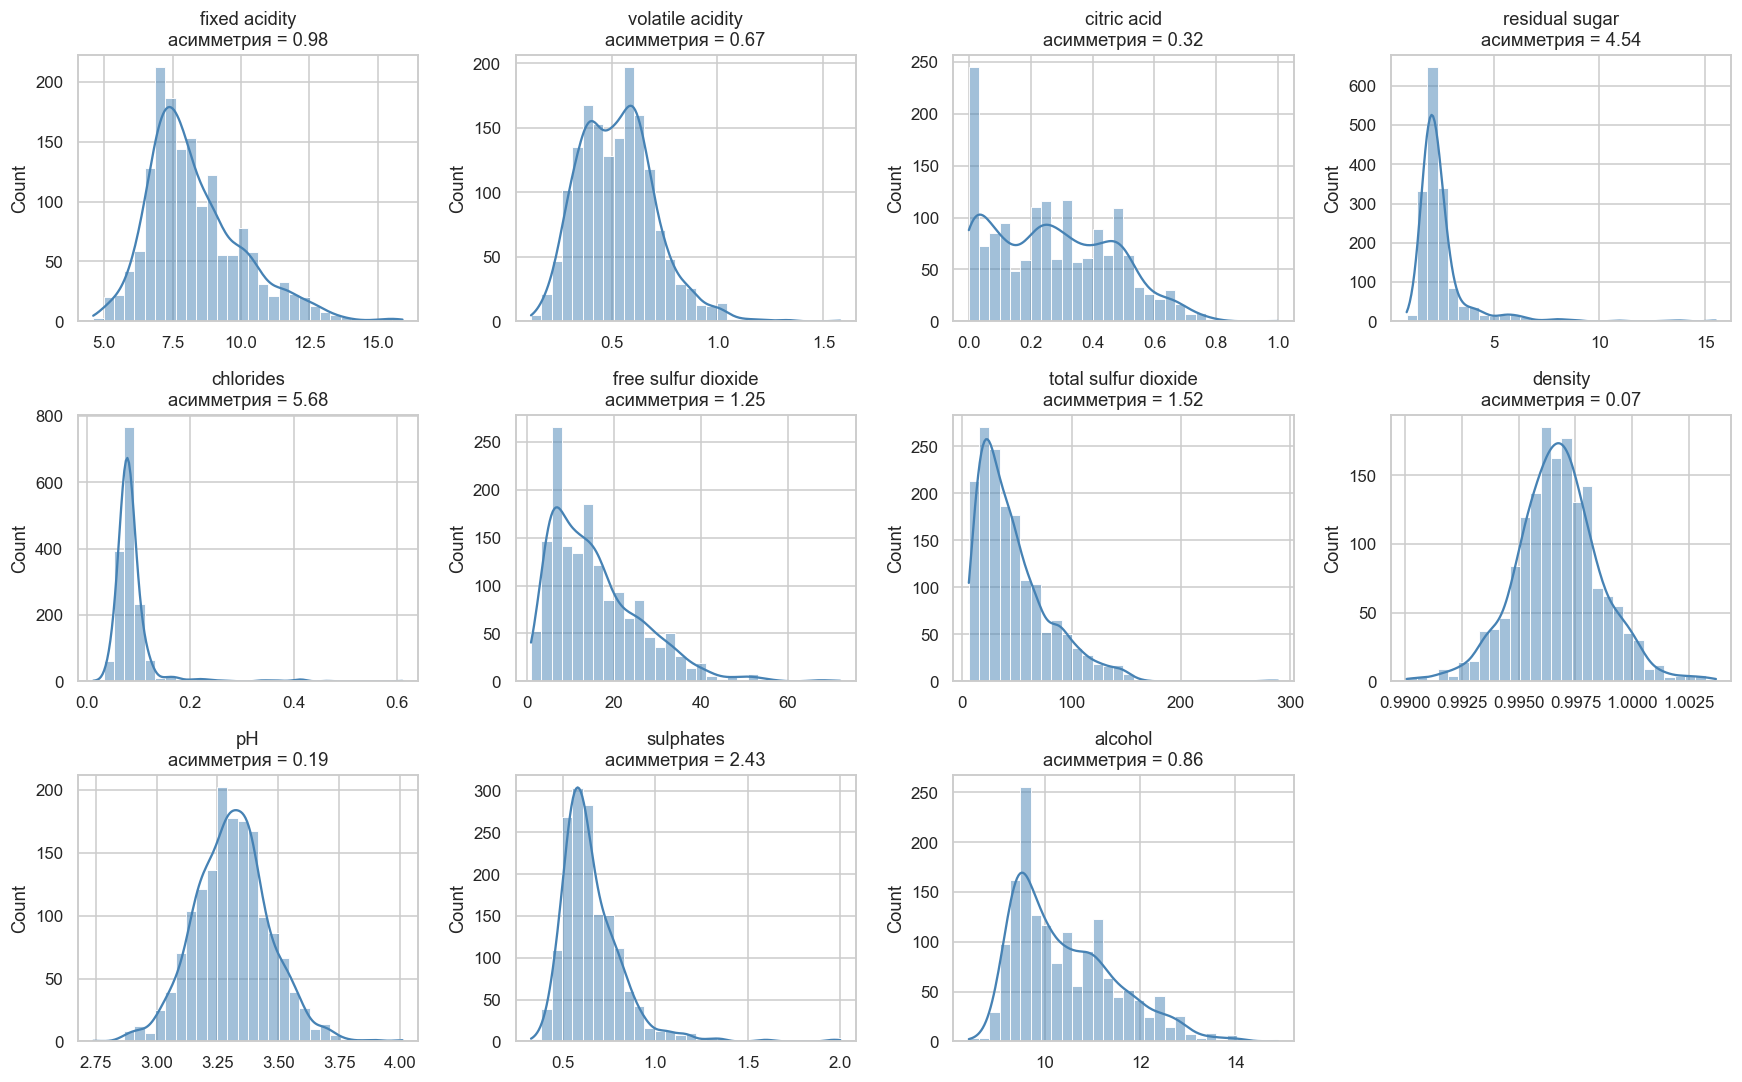

In [8]:
features = df.columns.drop("quality")
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.ravel(), features):
    sns.histplot(df[col], kde=True, bins=30, color="steelblue", ax=ax)
    ax.set_title(f"{col}\nасимметрия = {df[col].skew():.2f}")
    ax.set_xlabel("")
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

**Распределения признаков** (в заголовке каждого графика — коэффициент асимметрии):

- Близки к нормальным (асимметрия около 0): `density` (0.07), `pH` (0.19), `citric acid` (0.32, но с пиком в нуле — у многих вин лимонной кислоты нет).
- Умеренно скошены вправо: `volatile acidity`, `alcohol`, `fixed acidity` (0.7–1.0), `free sulfur dioxide` (1.25), `total sulfur dioxide` (1.5).
- **Сильно скошены вправо с длинным «хвостом» выбросов:** `sulphates` (2.4), `residual sugar` (4.5), `chlorides` (5.7). У большинства вин значения этих признаков малы, но есть единичные образцы с очень большими.

Вывод: данные не идеально нормальны, есть выбросы, но их немного и они отражают реальные особенности вин, поэтому выбросы **не удаляются** (иначе потеряем информацию и сократим и без того небольшую выборку). Линейная регрессия умеренно чувствительна к выбросам — это одна из причин, по которым не стоит ждать высокого R².

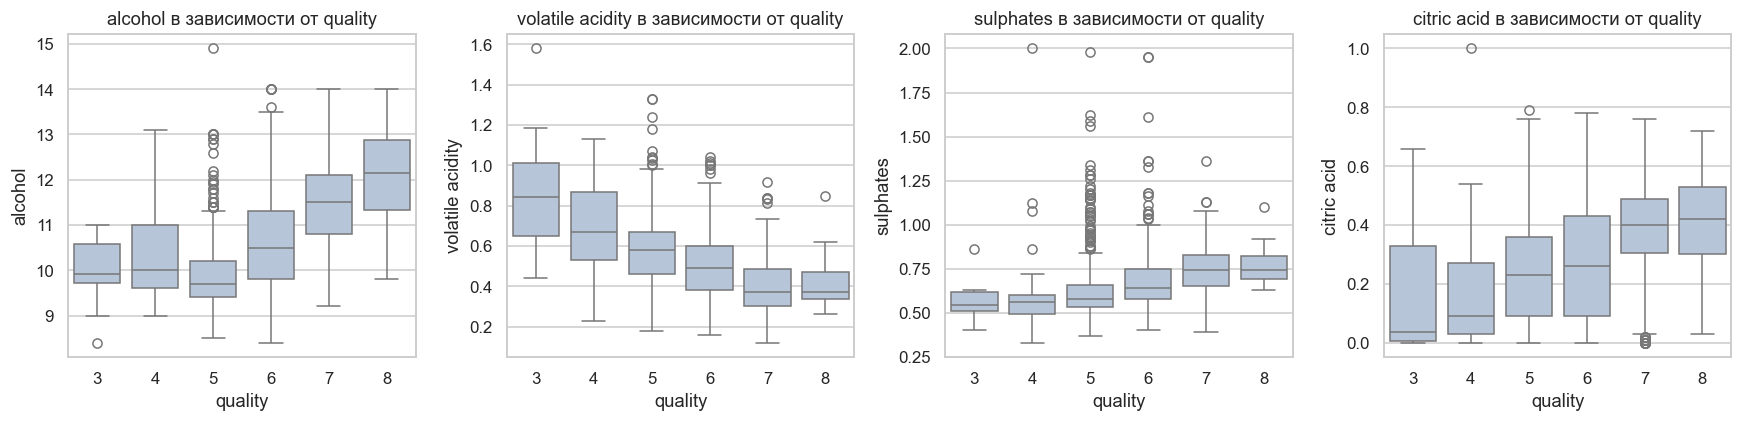

In [9]:
key = ["alcohol", "volatile acidity", "sulphates", "citric acid"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, key):
    sns.boxplot(x="quality", y=col, data=df, color="lightsteelblue", ax=ax)
    ax.set_title(f"{col} в зависимости от quality")
plt.tight_layout()
plt.show()

**Связь ключевых признаков с качеством** (ящики с усами по каждому значению `quality`):

- `alcohol`: чем выше качество, тем выше медианное содержание алкоголя — самая заметная положительная зависимость.
- `volatile acidity`: у более качественных вин летучих кислот меньше — отрицательная связь (уксусный привкус портит вино).
- `sulphates` и `citric acid`: слабая положительная связь, с заметным перекрытием между классами.

То есть зависимость целевой переменной от признаков есть и она приблизительно линейная (медианы меняются монотонно), поэтому линейная модель применима. Но перекрытие ящиков говорит о том, что отдельный признак качество не определяет: ожидать высокой точности не стоит.

In [10]:
n_before = len(df)

# 1. Пропуски: удаляем строки с пропусками (в этом датасете их нет, но шаг выполняем по заданию)
df_clean = df.dropna()
# 2. Полные дубликаты
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print(f"Было строк: {n_before}")
print(f"Стало строк: {len(df_clean)}  (удалено {n_before - len(df_clean)})")
print("Категориальных признаков нет, кодирование не требуется.")

X = df_clean.drop(columns="quality")
y = df_clean["quality"]
X.describe().loc[["min", "max", "mean", "std"]].T.round(3)

Было строк: 1599
Стало строк: 1359  (удалено 240)
Категориальных признаков нет, кодирование не требуется.


,min,max,mean,std
fixed acidity,4.600,15.900,8.311,1.737
volatile acidity,0.120,1.580,0.529,0.183
citric acid,0.000,1.000,0.272,0.196
residual sugar,0.900,15.500,2.523,1.352
chlorides,0.012,0.611,0.088,0.049
free sulfur dioxide,1.000,72.000,15.893,10.447
total sulfur dioxide,6.000,289.000,46.826,33.409
density,0.990,1.004,0.997,0.002
pH,2.740,4.010,3.310,0.155
sulphates,0.330,2.000,0.659,0.171


## 2. Подготовка данных

Выполнены следующие шаги:

1. **Пропуски** — вызван `dropna()`; пропусков в датасете нет, поэтому ни одна строка не потеряна.
2. **Дубликаты** — удалено 240 полностью совпадающих строк (описано выше), осталось **1359** уникальных образцов.
3. **Кодирование категориальных признаков** — не требуется (все признаки числовые).
4. **Выбросы** — сохранены (обоснование в анализе гистограмм).
5. Разделены матрица признаков `X` (11 столбцов) и целевая переменная `y = quality`.

Масштабы признаков отличаются на несколько порядков (например, `density` ≈ 1, `total sulfur dioxide` ≈ 47 в среднем, а стандартное отклонение — 0.002 против 33), поэтому дальше используется стандартизация `StandardScaler`.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Обучающая выборка:", X_train.shape, " Тестовая выборка:", X_test.shape)
print("Среднее quality: train =", round(y_train.mean(), 3), ", test =", round(y_test.mean(), 3))

Обучающая выборка: (1087, 11)  Тестовая выборка: (272, 11)
Среднее quality: train = 5.637 , test = 5.57


**Разбиение на обучающую и тестовую выборки** в пропорции 80/20 (`train_test_split`, `random_state=42`): 1087 образцов для обучения и 272 для теста. Средние значения `quality` в train (5.64) и test (5.57) близки, значит, разбиение получилось репрезентативным.

Важно: **тест не используется до финальной оценки**. Стандартизация и PCA обучаются только на train (через `Pipeline` ниже), иначе информация о тесте «просочилась» бы в модель (утечка данных).

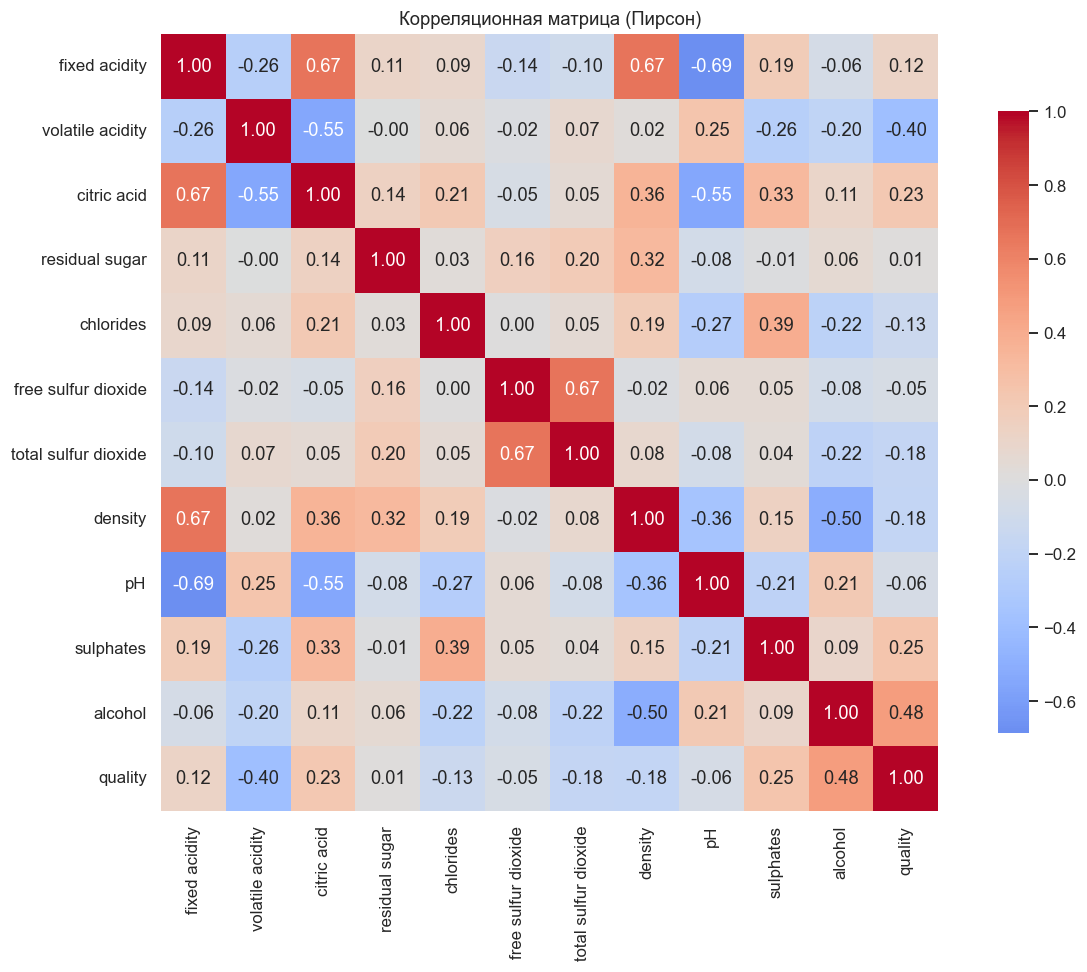


Корреляции с quality (по убыванию):
quality                 1.000000
alcohol                 0.480343
sulphates               0.248835
citric acid             0.228057
fixed acidity           0.119024
residual sugar          0.013640
free sulfur dioxide    -0.050463
pH                     -0.055245
chlorides              -0.130988
total sulfur dioxide   -0.177855
density                -0.184252
volatile acidity       -0.395214
Name: quality, dtype: float64


In [28]:
plt.figure(figsize=(12, 9))
corr = df_clean.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            square=True, cbar_kws={"shrink": .8})
plt.title("Корреляционная матрица (Пирсон)")
plt.tight_layout()
plt.savefig("fig2_corr_matrix.png", dpi=120, bbox_inches='tight')
plt.show()

print("\nКорреляции с quality (по убыванию):")
print(corr['quality'].sort_values(ascending=False))

## 3. Корреляционный анализ и мультиколлинеарность

**Корреляции с целевой переменной `quality`:**

- Самая сильная прямая связь: `alcohol` (r ≈ 0.48), затем `sulphates` (0.25) и `citric acid` (0.23).
- Самая сильная обратная связь: `volatile acidity` (r ≈ −0.40), далее `density` (−0.18) и `total sulfur dioxide` (−0.18).
- `residual sugar` (0.01), `free sulfur dioxide` и `pH` (около −0.05) почти не связаны с качеством линейно.

Ни один признак не имеет |r| выше 0.5, то есть качество вина зависит от **совокупности** факторов, а не от одного — это согласуется с ожидаемым умеренным R² линейной модели.

In [13]:
pairs = (corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
             .stack().rename("r").reset_index())
pairs.columns = ["Признак 1", "Признак 2", "r"]
pairs["|r|"] = pairs["r"].abs()
pairs.sort_values("|r|", ascending=False).head(6).round(3).reset_index(drop=True)

,Признак 1,Признак 2,r,|r|
0,fixed acidity,pH,-0.687,0.687
1,fixed acidity,density,0.670,0.670
2,fixed acidity,citric acid,0.667,0.667
3,free sulfur dioxide,total sulfur dioxide,0.667,0.667
4,volatile acidity,citric acid,-0.551,0.551
5,citric acid,pH,-0.550,0.550


**Корреляции между самими признаками** (это и есть источник мультиколлинеарности). Самые сильные пары:

- `fixed acidity` — `pH` (r = −0.69): чем больше кислот, тем ниже pH, связь физически очевидна.
- `fixed acidity` — `density` (0.67) и `fixed acidity` — `citric acid` (0.67).
- `free sulfur dioxide` — `total sulfur dioxide` (0.67): свободный SO₂ входит в состав общего.

Коэффициенты 0.55–0.69 — это умеренно высокая корреляция, и в центре почти всех пар стоит `fixed acidity`. Строгий вывод о мультиколлинеарности дает VIF, который учитывает зависимость признака сразу от всех остальных, а не только попарную.

In [14]:
# VIF считаем на стандартизованных признаках обучающей выборки + константа
X_std_tmp = pd.DataFrame(StandardScaler().fit_transform(X_train), columns=X_train.columns)
X_vif = sm.add_constant(X_std_tmp)
vif = pd.Series(
    [variance_inflation_factor(X_vif.values, i) for i in range(1, X_vif.shape[1])],
    index=X_train.columns, name="VIF"
).sort_values(ascending=False)
vif.round(3).to_frame()

,VIF
fixed acidity,7.946
density,6.310
pH,3.422
alcohol,3.163
citric acid,3.106
total sulfur dioxide,2.271
free sulfur dioxide,1.970
volatile acidity,1.762
residual sugar,1.613
chlorides,1.605


**VIF (Variance Inflation Factor)** показывает, во сколько раз растет дисперсия оценки коэффициента из-за линейной зависимости признака от остальных: VIF = 1 / (1 − R²ⱼ). Ориентиры: VIF < 5 — нет проблемы, 5–10 — умеренная мультиколлинеарность, > 10 — сильная.

Результаты:

- `fixed acidity`: **7.9** и `density`: **6.3** — превышают порог 5 (умеренная мультиколлинеарность, но не выше 10).
- Остальные признаки: от 1.5 до 3.4 — зависимость слабая.

Вывод: мультиколлинеарность **присутствует, но умеренная** и сосредоточена в группе `fixed acidity` – `density` – `pH` – `citric acid`. Для сравнения: если бы VIF был ниже 5 у всех признаков, PCA был бы не нужен; здесь он имеет смысл как средство её устранения. Считалось на стандартизованных данных, чтобы константа не искажала расчёт.

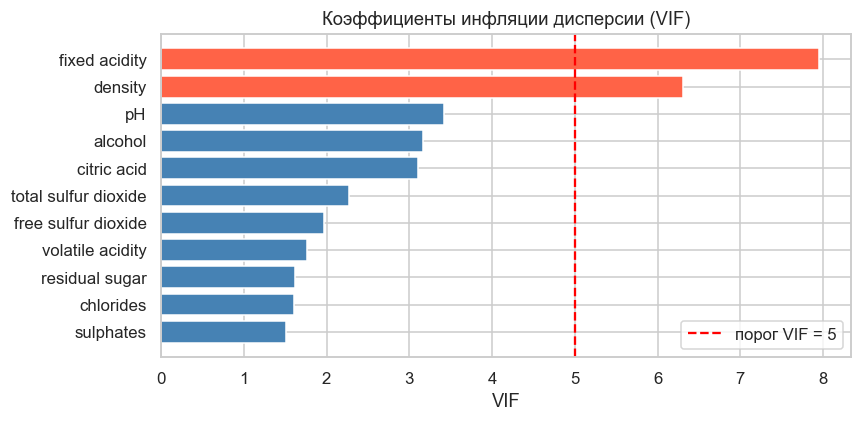

In [15]:
plt.figure(figsize=(8, 4))
colors = ["tomato" if v > 5 else "steelblue" for v in vif.values]
plt.barh(vif.index[::-1], vif.values[::-1], color=colors[::-1])
plt.axvline(5, color="red", ls="--", label="порог VIF = 5")
plt.xlabel("VIF")
plt.title("Коэффициенты инфляции дисперсии (VIF)")
plt.legend()
plt.tight_layout()
plt.show()

График наглядно показывает, что только два столбца (красные) пересекают пунктирный порог VIF = 5, а все остальные — заметно ниже. Серьезной «неустойчивости» коэффициентов ожидать не нужно, но у `fixed acidity` и `density` оценки коэффициентов в обычной линейной регрессии могут быть менее надёжными — это можно увидеть дальше при сравнении коэффициентов линейной модели и Lasso.

In [16]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate(name, model, Xtr, ytr, Xte, yte):
    """5-fold CV на train, затем обучение на всём train и оценка на test."""
    cv = cross_validate(model, Xtr, ytr, cv=kf,
                        scoring=("r2", "neg_root_mean_squared_error"))
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    return {
        "Модель": name,
        "CV R² (mean)": cv["test_r2"].mean(),
        "CV RMSE (mean)": -cv["test_neg_root_mean_squared_error"].mean(),
        "Test RMSE": np.sqrt(mean_squared_error(yte, pred)),
        "Test R²": r2_score(yte, pred),
        "Test MAPE (%)": mean_absolute_percentage_error(yte, pred) * 100,
    }

def make_pipe(model, pca_components=None):
    """Стандартизация -> (PCA) -> регрессия. Всё обучается только на train."""
    steps = [("scaler", StandardScaler())]
    if pca_components is not None:
        steps.append(("pca", PCA(n_components=pca_components, random_state=RANDOM_STATE)))
    steps.append(("model", model))
    return Pipeline(steps)

# проверка формул метрик на маленьком примере
y_true = np.array([5, 6, 7]); y_hat = np.array([5.5, 6, 6])
print("RMSE :", np.sqrt(np.mean((y_true - y_hat) ** 2)), "==", np.sqrt(mean_squared_error(y_true, y_hat)))
print("MAPE%:", np.mean(np.abs((y_true - y_hat) / y_true)) * 100, "==", mean_absolute_percentage_error(y_true, y_hat) * 100)

RMSE : 0.6454972243679028 == 0.6454972243679028
MAPE%: 8.095238095238095 == 8.095238095238095


## 4. Регрессионные модели до устранения мультиколлинеарности

**Функции для оценки.** `evaluate` выполняет 5-кратную кросс-валидацию на обучающей выборке (`KFold`, с перемешиванием), затем обучает модель на всём train и считает метрики на отложенном test:

- **RMSE** = √(mean((y − ŷ)²)) — ошибка в тех же единицах, что `quality` (баллы);
- **R²** = 1 − SS_res/SS_tot — доля объяснённой дисперсии;
- **MAPE** = mean(|y − ŷ| / |y|) · 100% — средняя относительная ошибка.

`make_pipe` собирает `Pipeline`: стандартизация → (PCA) → регрессия. Благодаря конвейеру `StandardScaler` и PCA обучаются **внутри каждого фолда** только на обучающей части, поэтому в кросс-валидацию не попадает утечка. Проверка на маленьком примере показала, что формулы RMSE и MAPE, посчитанные вручную, совпадают с `sklearn`.

In [17]:
base_models = {
    "Линейная регрессия": make_pipe(LinearRegression()),
    "Гребневая (α=1.0)":  make_pipe(Ridge(alpha=1.0)),
    "Lasso (α=0.01)":     make_pipe(Lasso(alpha=0.01)),
}
res_base = pd.DataFrame([evaluate(n, m, X_train, y_train, X_test, y_test)
                         for n, m in base_models.items()]).set_index("Модель")
res_base.round(4)

,CV R² (mean),CV RMSE (mean),Test RMSE,Test R²,Test MAPE (%)
Модель,,,,,
Линейная регрессия,0.3209,0.6684,0.6565,0.3915,9.6757
Гребневая (α=1.0),0.3211,0.6684,0.6564,0.3918,9.6747
Lasso (α=0.01),0.3260,0.6663,0.6522,0.3995,9.6185


**Метрики моделей на исходных признаках (до PCA):**

| Модель | CV R² | Test RMSE | Test R² | Test MAPE |
| --- | --- | --- | --- | --- |
| Линейная | 0.321 | 0.657 | 0.392 | 9.68% |
| Гребневая (α=1) | 0.321 | 0.656 | 0.392 | 9.67% |
| Lasso (α=0.01) | 0.326 | 0.652 | 0.400 | 9.62% |

Интерпретация:
- Все три модели дают близкое качество: **R² ≈ 0.39–0.40** (объясняется около 40% дисперсии качества), RMSE ≈ 0.65 балла, MAPE ≈ 9.6%. Это умеренный результат, типичный для этого датасета: качество вина — субъективная экспертная оценка, на которую влияют факторы, которых нет в данных.
- Ridge при α=1 совпадает с обычной регрессией: штраф слишком мал по сравнению с размером выборки, чтобы изменить коэффициенты.
- Lasso немного лучше (R² 0.400 против 0.392): L1-штраф обнулил малозначимые признаки и чуть снизил переобучение. Разница, однако, невелика и сопоставима с шумом (тест — всего 272 образца).
- CV R² (≈ 0.32) ниже, чем Test R² (≈ 0.39): на данном разбиении тест оказался «легче» средней валидационной части. Для сравнения моделей надёжнее ориентироваться на CV R², так как он усредняет пять разбиений.

In [18]:
coefs = pd.DataFrame({
    n: m.named_steps["model"].coef_ for n, m in base_models.items()
}, index=X_train.columns)
coefs.round(3)

,Линейная регрессия,Гребневая (α=1.0),Lasso (α=0.01)
fixed acidity,-0.050,-0.048,0.000
volatile acidity,-0.178,-0.178,-0.170
citric acid,-0.019,-0.019,-0.000
residual sugar,-0.005,-0.005,0.000
chlorides,-0.116,-0.116,-0.096
free sulfur dioxide,0.049,0.048,0.019
total sulfur dioxide,-0.124,-0.123,-0.090
density,0.042,0.040,-0.000
pH,-0.122,-0.120,-0.071
sulphates,0.148,0.149,0.137


**Коэффициенты моделей** (на стандартизованных признаках, поэтому их можно сравнивать между собой по величине):

- Самые влиятельные признаки во всех моделях: `alcohol` (+0.33), `volatile acidity` (−0.18), `sulphates` (+0.15), `total sulfur dioxide` (−0.12), `chlorides` (−0.12), `pH` (−0.12). Знаки совпадают с корреляционным анализом и с «химическим смыслом».
- **Lasso обнулил четыре признака:** `fixed acidity`, `citric acid`, `residual sugar` и `density`. Заметьте, что это в основном именно те признаки, которые имели высокий VIF или малую корреляцию с целью, то есть Lasso сам провёл отбор признаков и частично устранил мультиколлинеарность.
- У Ridge коэффициенты почти не отличаются от обычной регрессии (α=1 мал).

In [19]:
alphas = np.logspace(-4, 3, 60)

grid_ridge = GridSearchCV(make_pipe(Ridge()), {"model__alpha": alphas}, cv=kf, scoring="r2").fit(X_train, y_train)
grid_lasso = GridSearchCV(make_pipe(Lasso(max_iter=10000)), {"model__alpha": np.logspace(-4, 0, 60)}, cv=kf, scoring="r2").fit(X_train, y_train)

a_ridge = grid_ridge.best_params_["model__alpha"]
a_lasso = grid_lasso.best_params_["model__alpha"]
print(f"Лучший alpha для Ridge: {a_ridge:.4f}")
print(f"Лучший alpha для Lasso: {a_lasso:.5f}")

tuned_models = {
    f"Гребневая (α={a_ridge:.2f}, подобран)": make_pipe(Ridge(alpha=a_ridge)),
    f"Lasso (α={a_lasso:.4f}, подобран)":     make_pipe(Lasso(alpha=a_lasso, max_iter=10000)),
}
res_tuned = pd.DataFrame([evaluate(n, m, X_train, y_train, X_test, y_test)
                          for n, m in tuned_models.items()]).set_index("Модель")
res_before = pd.concat([res_base, res_tuned])
res_before.round(4)

Лучший alpha для Ridge: 49.5354
Лучший alpha для Lasso: 0.00677


,CV R² (mean),CV RMSE (mean),Test RMSE,Test R²,Test MAPE (%)
Модель,,,,,
Линейная регрессия,0.3209,0.6684,0.6565,0.3915,9.6757
Гребневая (α=1.0),0.3211,0.6684,0.6564,0.3918,9.6747
Lasso (α=0.01),0.3260,0.6663,0.6522,0.3995,9.6185
"Гребневая (α=49.54, подобран)",0.3233,0.6675,0.6538,0.3965,9.6690
"Lasso (α=0.0068, подобран)",0.3263,0.6661,0.6524,0.3991,9.6214


**Подбор гиперпараметра α** (`GridSearchCV` с той же 5-кратной кросс-валидацией по R²). Найдено: для Ridge **α ≈ 49.5**, для Lasso **α ≈ 0.0068**.

- Подобранный Ridge (R² теста 0.397) чуть лучше Ridge с α=1 (0.392): более сильная регуляризация слегка уменьшает влияние коррелирующих признаков.
- Подобранный Lasso (0.399) практически не отличается от Lasso с α=0.01 (0.400) — значения α близки.

Подбор α дал лишь небольшой выигрыш (в третьем знаке): это значит, что **регуляризация не является главным резервом улучшения** — главное ограничение лежит в самих данных (шум, неучтённые факторы, дискретная целевая переменная).

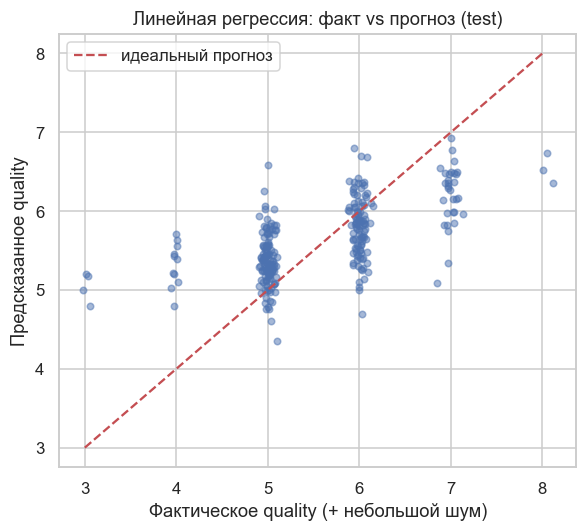

In [20]:
lin = base_models["Линейная регрессия"]
pred_lin = lin.predict(X_test)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(y_test + np.random.default_rng(0).normal(0, 0.05, len(y_test)), pred_lin, alpha=0.5, s=18)
ax.plot([3, 8], [3, 8], "r--", label="идеальный прогноз")
ax.set_xlabel("Фактическое quality (+ небольшой шум)")
ax.set_ylabel("Предсказанное quality")
ax.set_title("Линейная регрессия: факт vs прогноз (test)")
ax.legend()
plt.tight_layout()
plt.show()

**График «факт — прогноз»** для линейной модели на тесте. Реальные оценки целые, поэтому точки выстроены вертикальными колонками (для наглядности добавлен небольшой шум по оси X). Видно, что:

- прогнозы сосредоточены в диапазоне примерно 4.5–7, причём основная масса лежит между 5 и 6.5, хотя фактические оценки лежат в диапазоне 3–8;
- для редких крайних оценок (3–4 и 7–8) модель систематически ошибается: низкие оценки завышает, высокие занижает (эффект «регрессии к среднему»).

Именно поэтому R² не превышает 0.4: линейная модель хорошо ловит общий тренд, но не может предсказать редкие и экстремальные оценки.

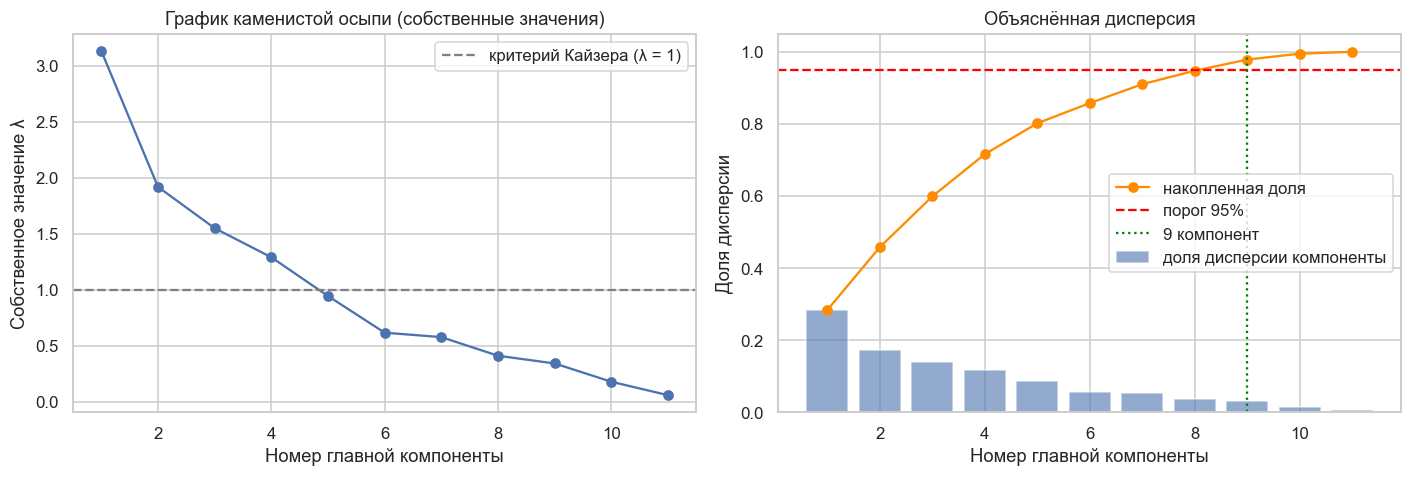

          λ   доля  накопленная
PC1   3.130  0.284        0.284
PC2   1.917  0.174        0.458
PC3   1.549  0.141        0.599
PC4   1.289  0.117        0.716
PC5   0.943  0.086        0.802
PC6   0.616  0.056        0.858
PC7   0.577  0.052        0.910
PC8   0.411  0.037        0.947
PC9   0.342  0.031        0.978
PC10  0.179  0.016        0.995
PC11  0.059  0.005        1.000

Для 95% дисперсии нужно компонент: 9 из 11


In [21]:
scaler_full = StandardScaler().fit(X_train)
X_train_std = scaler_full.transform(X_train)

pca_full = PCA(random_state=RANDOM_STATE).fit(X_train_std)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)
n_pc = int(np.argmax(cum >= 0.95) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
k = np.arange(1, len(evr) + 1)
axes[0].plot(k, pca_full.explained_variance_, "o-")
axes[0].axhline(1, color="gray", ls="--", label="критерий Кайзера (λ = 1)")
axes[0].set_title("График каменистой осыпи (собственные значения)")
axes[0].set_xlabel("Номер главной компоненты"); axes[0].set_ylabel("Собственное значение λ")
axes[0].legend()

axes[1].bar(k, evr, alpha=0.6, label="доля дисперсии компоненты")
axes[1].plot(k, cum, "o-", color="darkorange", label="накопленная доля")
axes[1].axhline(0.95, color="red", ls="--", label="порог 95%")
axes[1].axvline(n_pc, color="green", ls=":", label=f"{n_pc} компонент")
axes[1].set_title("Объяснённая дисперсия")
axes[1].set_xlabel("Номер главной компоненты"); axes[1].set_ylabel("Доля дисперсии")
axes[1].legend()
plt.tight_layout()
plt.show()

print(pd.DataFrame({"λ": pca_full.explained_variance_, "доля": evr, "накопленная": cum},
                   index=[f"PC{i}" for i in k]).round(3))
print(f"\nДля 95% дисперсии нужно компонент: {n_pc} из {len(evr)}")

## 5. Устранение мультиколлинеарности: метод главных компонент (PCA)

Перед PCA признаки **стандартизованы** (среднее 0, дисперсия 1) — иначе компоненты определялись бы признаками с наибольшим масштабом (`total sulfur dioxide`). 

**График каменистой осыпи** (слева — собственные значения, справа — доля объяснённой дисперсии и накопленная доля):

- Кривая падает плавно: заметен лишь мягкий излом около 4–5 компонент, после которого она идёт полого. Первые компоненты объясняют 28%, 17%, 14%, 12% дисперсии.
- По **критерию Кайзера** (оставлять компоненты с λ > 1) достаточно 4 компонент, но они объясняют лишь 72% дисперсии.
- По порогу **95% накопленной дисперсии** нужно **9 из 11** компонент (97.8%; восьми компонент не хватает — 94.7%). Этот критерий и выбран для дальнейшей работы, чтобы не потерять информацию.

Вывод: сжать 11 признаков в 2–3 компоненты без потерь нельзя — это говорит о том, что мультиколлинеарность умеренная (VIF 6–8, а не 50), и большая часть признаков несёт независимую информацию.

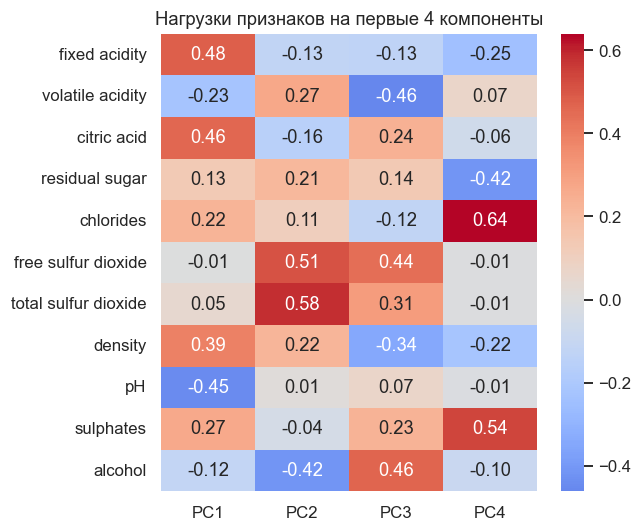

In [22]:
loadings = pd.DataFrame(pca_full.components_[:4].T, index=X_train.columns,
                        columns=[f"PC{i}" for i in range(1, 5)])
plt.figure(figsize=(6, 5))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Нагрузки признаков на первые 4 компоненты")
plt.tight_layout()
plt.show()

**Нагрузки** показывают, из каких исходных признаков «собрана» каждая компонента (чем больше |значение|, тем сильнее вклад).

- **PC1** — «кислотность»: высокие нагрузки у `fixed acidity`, `citric acid`, `density` (с одним знаком) и `pH` (с противоположным). Именно здесь собирается группа коррелирующих признаков с большим VIF.
- **PC2** — «сернистый ангидрид»: `free` и `total sulfur dioxide`.
- **PC3** противопоставляет `alcohol` и SO₂ (с плюсом) летучим кислотам (с минусом); **PC4** — «хлориды и сульфаты» (соли). Эти компоненты объясняют уже меньше дисперсии и отражают более узкие факторы.

Таким образом, PCA сжал коррелирующую группу кислотных признаков в одну компоненту, что и устраняет мультиколлинеарность.

In [23]:
pcs_train = make_pipe(LinearRegression(), n_pc)[:-1].fit_transform(X_train)
pcs_df = pd.DataFrame(pcs_train, columns=[f"PC{i}" for i in range(1, n_pc + 1)])
vif_pc = pd.Series(
    [variance_inflation_factor(sm.add_constant(pcs_df).values, i) for i in range(1, n_pc + 1)],
    index=pcs_df.columns, name="VIF"
)
print("Максимальный VIF на главных компонентах:", round(vif_pc.max(), 4))
print("Максимальная |корреляция| между компонентами:",
      round(np.abs(np.corrcoef(pcs_train.T) - np.eye(n_pc)).max(), 10))
vif_pc.round(4).to_frame().T

Максимальный VIF на главных компонентах: 1.0
Максимальная |корреляция| между компонентами: 0.0


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
VIF,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


**Проверка устранения мультиколлинеарности.** После PCA максимальный VIF равен **1.0**, а корреляция между любыми двумя компонентами — 0 (с точностью вычислений). Компоненты ортогональны по построению, поэтому мультиколлинеарность устранена полностью, чего нельзя было сказать об исходных признаках (VIF до 7.9).

In [24]:
pca_models = {
    "Линейная регрессия": make_pipe(LinearRegression(), n_pc),
    "Гребневая (α=1.0)":  make_pipe(Ridge(alpha=1.0), n_pc),
    "Lasso (α=0.01)":     make_pipe(Lasso(alpha=0.01), n_pc),
    f"Гребневая (α={a_ridge:.2f}, подобран)": make_pipe(Ridge(alpha=a_ridge), n_pc),
    f"Lasso (α={a_lasso:.4f}, подобран)":     make_pipe(Lasso(alpha=a_lasso, max_iter=10000), n_pc),
}
res_pca = pd.DataFrame([evaluate(n, m, X_train, y_train, X_test, y_test)
                        for n, m in pca_models.items()]).set_index("Модель")
res_pca.round(4)

,CV R² (mean),CV RMSE (mean),Test RMSE,Test R²,Test MAPE (%)
Модель,,,,,
Линейная регрессия,0.3205,0.6689,0.6520,0.3998,9.6540
Гребневая (α=1.0),0.3205,0.6689,0.6520,0.3998,9.6542
Lasso (α=0.01),0.3193,0.6695,0.6517,0.4004,9.6550
"Гребневая (α=49.54, подобран)",0.3214,0.6686,0.6529,0.3982,9.6711
"Lasso (α=0.0068, подобран)",0.3200,0.6692,0.6516,0.4006,9.6521


## 6. Регрессия на главных компонентах (после PCA)

Те же модели (линейная, Ridge, Lasso, плюс версии с подобранными α), но признаками служат 9 главных компонент. Конвейер `стандартизация → PCA(9) → регрессия` обучается только на train.

**Результаты после PCA:**

| Модель | CV R² | Test RMSE | Test R² | Test MAPE |
| --- | --- | --- | --- | --- |
| Линейная | 0.3205 | 0.652 | 0.400 | 9.65% |
| Гребневая (α=1) | 0.3205 | 0.652 | 0.400 | 9.65% |
| Lasso (α=0.01) | 0.3193 | 0.652 | 0.400 | 9.66% |

Все пять моделей по-прежнему дают практически одинаковые метрики. Ridge и линейная регрессия совпали ещё сильнее, чем до PCA: у ортогональных признаков нет мультиколлинеарности, которую мог бы гасить L2-штраф.

CV R² (mean)  \
Набор признаков         Модель                                        
До PCA (11 признаков)   Линейная регрессия                   0.3209   
                        Гребневая (α=1.0)                    0.3211   
                        Lasso (α=0.01)                       0.3260   
                        Гребневая (α=49.54, подобран)        0.3233   
                        Lasso (α=0.0068, подобран)           0.3263   
После PCA (9 компонент) Линейная регрессия                   0.3205   
                        Гребневая (α=1.0)                    0.3205   
                        Lasso (α=0.01)                       0.3193   
                        Гребневая (α=49.54, подобран)        0.3214   
                        Lasso (α=0.0068, подобран)           0.3200   

                                                       Test RMSE  Test R²  \
Набор признаков         Модель                                              
До PCA (11 признаков)   Линейная регрессия                0.6565   0.3915   
                        Гребневая (α=1.0)                 0.6564   0.3918   
                        Lasso (α=0.01)                    0.6522   0.3995   
                        Гребневая (α=49.54, подобран)     0.6538   0.3965   
                        Lasso (α=0.0068, подобран)        0.6524   0.3991   
После PCA (9 компонент) Линейная регрессия                0.6520   0.3998   
                        Гребневая (α=1.0)                 0.6520   0.3998   
                        Lasso (α=0.01)                    0.6517   0.4004   
                        Гребневая (α=49.54, подобран)     0.6529   0.3982   
                        Lasso (α=0.0068, подобран)        0.6516   0.4006   

                                                       Test MAPE (%)  
Набор признаков         Модель                                        
До PCA (11 признаков)   Линейная регрессия                    9.6757  
                        Гребневая (α=1.0)                     9.6747  
                        Lasso (α=0.01)                        9.6185  
                        Гребневая (α=49.54, подобран)         9.6690  
                        Lasso (α=0.0068, подобран)            9.6214  
После PCA (9 компонент) Линейная регрессия                    9.6540  
                        Гребневая (α=1.0)                     9.6542  
                        Lasso (α=0.01)                        9.6550  
                        Гребневая (α=49.54, подобран)         9.6711  
                        Lasso (α=0.0068, подобран)            9.6521

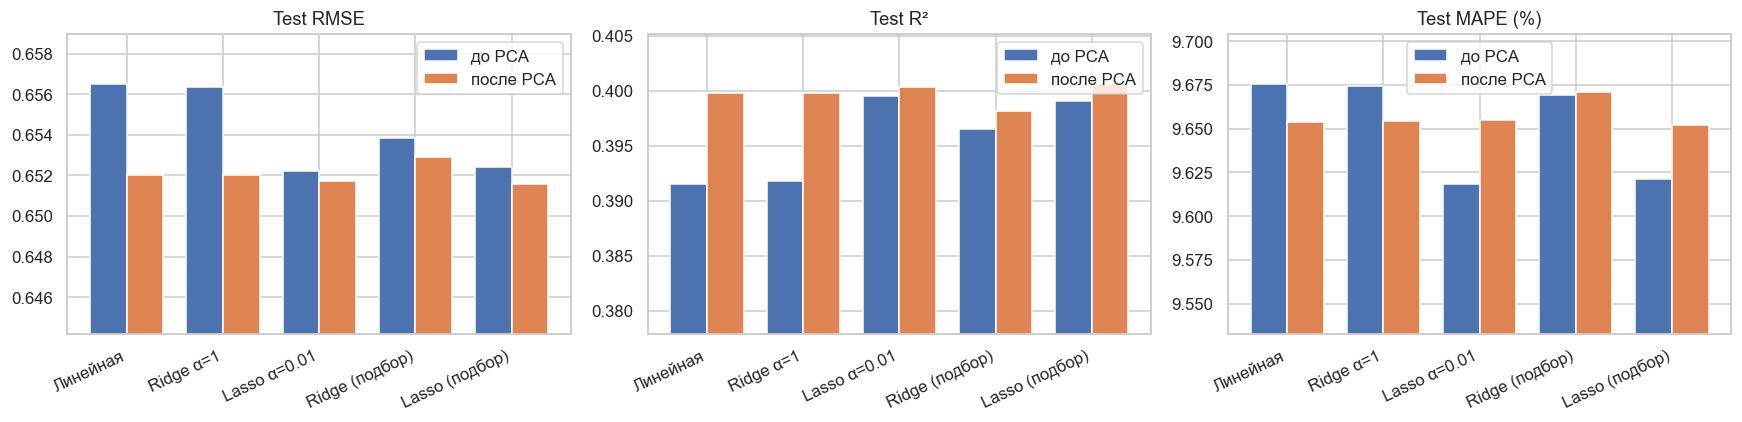

In [25]:
compare = pd.concat({"До PCA (11 признаков)": res_before,
                     f"После PCA ({n_pc} компонент)": res_pca}, names=["Набор признаков"])
display(compare[["CV R² (mean)", "Test RMSE", "Test R²", "Test MAPE (%)"]].round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
labels = ["Линейная", "Ridge α=1", "Lasso α=0.01", "Ridge (подбор)", "Lasso (подбор)"]
x = np.arange(len(labels)); w = 0.38
for ax, col in zip(axes, ["Test RMSE", "Test R²", "Test MAPE (%)"]):
    ax.bar(x - w/2, res_before[col].values, w, label="до PCA")
    ax.bar(x + w/2, res_pca[col].values, w, label="после PCA")
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=25, ha="right")
    ax.set_title(col); ax.legend()
    lo, hi = min(res_before[col].min(), res_pca[col].min()), max(res_before[col].max(), res_pca[col].max())
    ax.set_ylim(lo - (hi - lo) * 1.5, hi + (hi - lo) * 0.5)
plt.tight_layout()
plt.show()

## 7. Сравнение моделей до и после PCA

Сводная таблица и столбчатые диаграммы Test RMSE, R² и MAPE.

- **Линейная регрессия:** CV R² 0.3209 → 0.3205 (практически без изменений); Test R² 0.3915 → 0.3998; Test RMSE 0.6565 → 0.6520.
- **Lasso (α=0.01):** CV R² 0.3260 → 0.3193 (чуть хуже), Test R² 0.3995 → 0.4004 — почти то же самое.
- Лучшая CV R² по-прежнему у Lasso на исходных признаках (0.3263), лучший Test R² — у Lasso на компонентах (0.4006), но разница между всеми вариантами **меньше 0.01** по R² и 0.01 балла по RMSE.

**Выводы:**
1. PCA **не ухудшил и не улучшил** качество: различия лежат в пределах статистического шума (тест — 272 образца), поэтому утверждать, что PCA «помог» из-за прироста Test R² на 0.008, нельзя — по кросс-валидации модели равны.
2. Зато PCA **устранил мультиколлинеарность** (VIF 1.0) и сократил размерность с 11 до 9 признаков **без потери качества**, но ценой интерпретируемости: компоненты — это смеси исходных признаков, и смысл коэффициентов уже не такой прозрачный, как у `alcohol` или `volatile acidity`.
3. Lasso на исходных признаках решает ту же задачу (отбор признаков и ослабление коллинеарности) и сохраняет интерпретируемость.

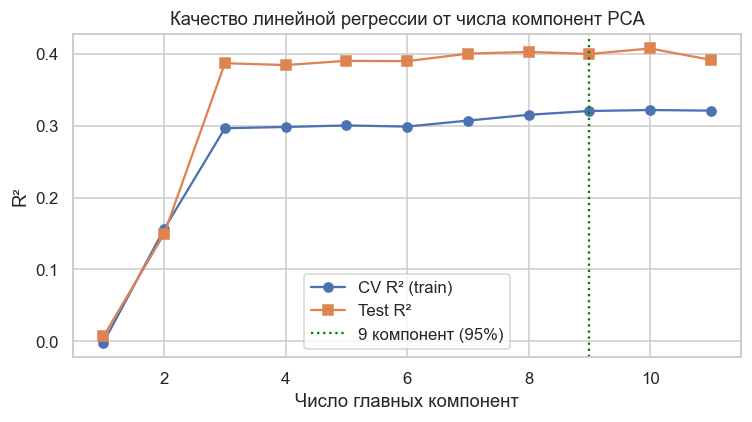

,Накопл. дисперсия,CV R²,Test R²,Test RMSE
Число компонент,,,,
1,0.2843,-0.0020,0.0066,0.8389
2,0.4583,0.1561,0.1494,0.7762
3,0.5990,0.2964,0.3869,0.6590
4,0.7161,0.2982,0.3844,0.6604
5,0.8018,0.3003,0.3903,0.6572
6,0.8577,0.2987,0.3898,0.6574
7,0.9101,0.3071,0.4003,0.6518
8,0.9474,0.3151,0.4026,0.6505
9,0.9784,0.3205,0.3998,0.6520


In [26]:
rows = []
for k_ in range(1, X_train.shape[1] + 1):
    m = make_pipe(LinearRegression(), k_)
    r = evaluate(f"{k_}", m, X_train, y_train, X_test, y_test)
    rows.append({"Число компонент": k_, "Накопл. дисперсия": cum[k_ - 1],
                 "CV R²": r["CV R² (mean)"], "Test R²": r["Test R²"], "Test RMSE": r["Test RMSE"]})
kscan = pd.DataFrame(rows).set_index("Число компонент")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(kscan.index, kscan["CV R²"], "o-", label="CV R² (train)")
ax.plot(kscan.index, kscan["Test R²"], "s-", label="Test R²")
ax.axvline(n_pc, color="green", ls=":", label=f"{n_pc} компонент (95%)")
ax.set_xlabel("Число главных компонент"); ax.set_ylabel("R²")
ax.set_title("Качество линейной регрессии от числа компонент PCA")
ax.legend()
plt.tight_layout()
plt.show()
kscan.round(4)

**Зависимость качества от числа компонент.** Нарастающее качество линейной регрессии при добавлении компонент:

- 1–2 компоненты дают очень плохой результат (Test R² 0.01 и 0.15) — слишком много информации потеряно.
- Начиная с **3 компонент** R² на тесте выходит на плато (≈ 0.38–0.40), а CV R² продолжает слабо расти до 9–10 компонент (0.32).
- Между 9 и 11 компонентами разницы нет: добавление последних компонент (они объясняют менее 2% дисперсии) ничего не даёт.

Это подтверждает выбор порога 95% (9 компонент) как разумного компромисса: дальнейшее увеличение числа компонент не улучшает метрики, а сокращение ниже 7–8 уже ухудшает CV R².

Тест Бреуша–Пагана (до PCA): p-value = 2.144e-09  -> гетероскедастичность
Тест Бреуша–Пагана (после PCA): p-value = 4.256e-07  -> гетероскедастичность


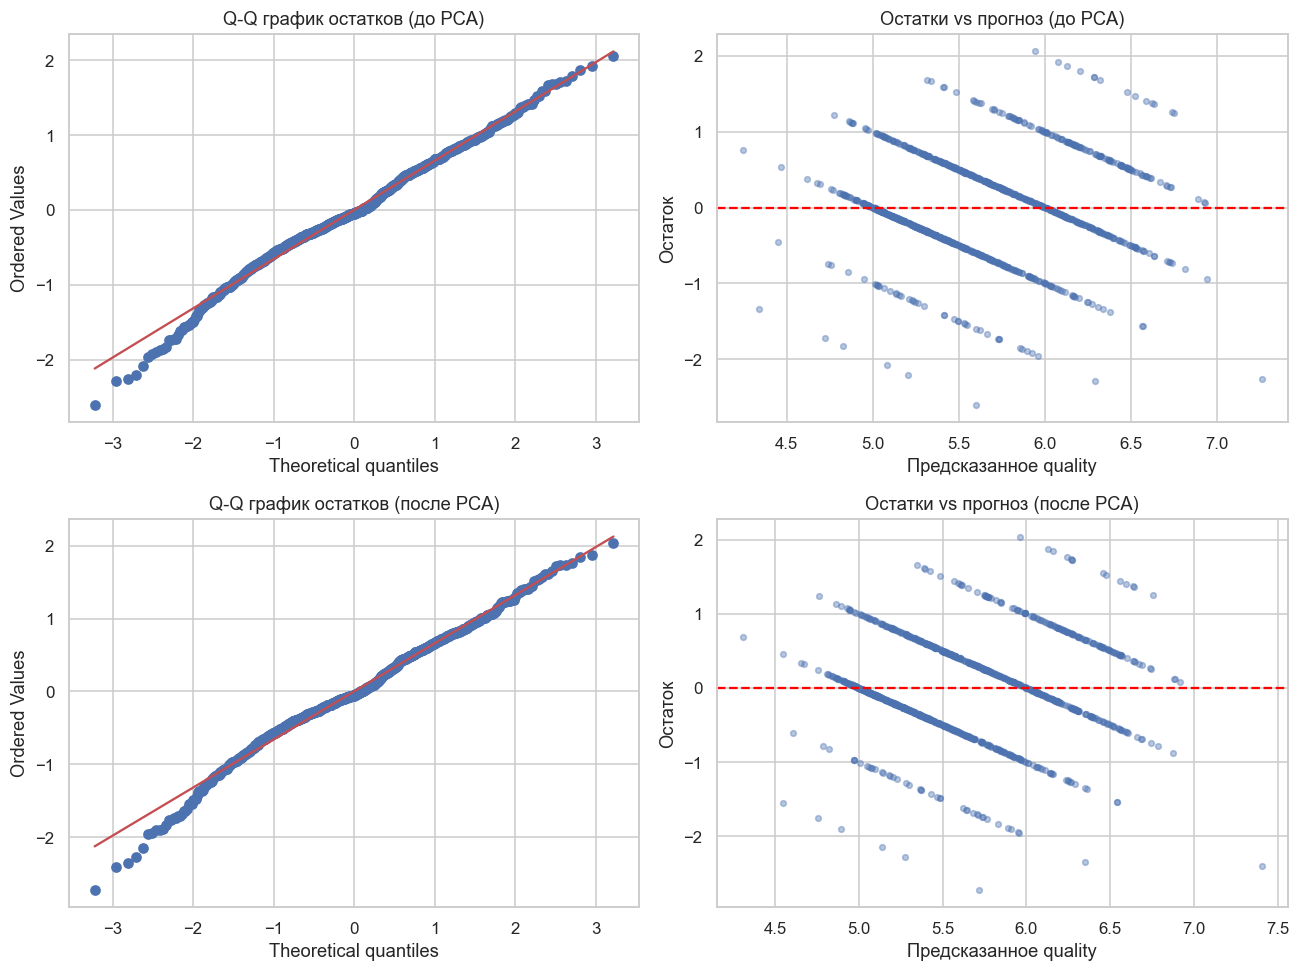

In [27]:
def residual_report(model, title):
    pred_tr = model.predict(X_train)
    resid = y_train - pred_tr
    # признаки, на которых реально обучалась регрессия (после scaler/PCA)
    feats = model[:-1].transform(X_train)
    bp_stat, bp_p, _, _ = het_breuschpagan(resid, sm.add_constant(feats))
    return resid, pred_tr, bp_p

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for row, (name, mdl) in enumerate([("до PCA", base_models["Линейная регрессия"]),
                                    ("после PCA", pca_models["Линейная регрессия"])]):
    resid, pred_tr, bp_p = residual_report(mdl, name)
    stats.probplot(resid, dist="norm", plot=axes[row, 0])
    axes[row, 0].set_title(f"Q-Q график остатков ({name})")
    axes[row, 1].scatter(pred_tr, resid, alpha=0.4, s=14)
    axes[row, 1].axhline(0, color="red", ls="--")
    axes[row, 1].set_xlabel("Предсказанное quality"); axes[row, 1].set_ylabel("Остаток")
    axes[row, 1].set_title(f"Остатки vs прогноз ({name})")
    print(f"Тест Бреуша–Пагана ({name}): p-value = {bp_p:.4g}  ->",
          "гетероскедастичность" if bp_p < 0.05 else "гомоскедастичность не отвергается")
plt.tight_layout()
plt.show()

## 8. Анализ остатков

Проверяем предпосылки метода наименьших квадратов для линейной модели (до и после PCA).

- **Q-Q график:** точки в центре лежат вдоль диагонали, то есть остатки приблизительно нормальны; на концах заметны отклонения — следствие дискретной целевой переменной и редких крайних оценок.
- **Остатки против прогнозов:** точки лежат «полосами» (из-за целых значений `quality`), разброс примерно одинаков вдоль оси, но слегка шире для крайних прогнозов.
- **Тест Бреуша–Пагана:** p-value ≈ 2·10⁻⁹ (до PCA) и ≈ 4·10⁻⁷ (после PCA) — обе меньше 0.05, **гипотеза о гомоскедастичности отвергается**, то есть дисперсия ошибок не строго постоянна.

Вывод: нарушения нормальности и гомоскедастичности небольшие и ожидаемы для дискретной субъективной оценки. Для прогнозных целей модель остаётся пригодной, но доверительные интервалы коэффициентов следует считать приблизительными (для точных выводов можно применить робастные ошибки или преобразование целевой переменной).

## Заключение

1. **Датасет** Red Wine Quality (1599 образцов, 11 числовых признаков) очищен от 240 дубликатов; пропусков нет. Целевая переменная `quality` дискретна и сосредоточена в значениях 5 и 6.
2. **Мультиколлинеарность** в исходных данных умеренная: VIF у `fixed acidity` (7.9) и `density` (6.3) выше порога 5, но ниже 10; у остальных признаков — меньше 3.5.
3. **Модели до PCA** (линейная, Ridge, Lasso) дают R² ≈ 0.39–0.40, RMSE ≈ 0.65, MAPE ≈ 9.6%. Наиболее значимые признаки: `alcohol` (+), `volatile acidity` (−), `sulphates` (+). Lasso обнулил `fixed acidity`, `citric acid`, `residual sugar` и `density`.
4. **PCA** со стандартизацией сжал данные до 9 компонент (95% дисперсии) и снизил VIF до 1.0. Метрики моделей на компонентах практически не изменились (R² ≈ 0.40, RMSE ≈ 0.652): разница между вариантами меньше шума.
5. **Предел точности** (R² ≈ 0.4) определяется данными, а не выбором метода: оценка вина субъективна, целевая переменная дискретна, а крайние оценки редки. Ни подбор α, ни PCA, ни регуляризация существенного выигрыша не дали.
6. **Как можно улучшить результат:** нелинейные модели (случайный лес, градиентный бустинг), добавление взаимодействий признаков, логарифмирование скошенных признаков (`chlorides`, `residual sugar`, `sulphates`), постановка задачи как классификации (например, «хорошее» ≥ 7 / «обычное»).

